MODEL TRAINING

In [1]:
import pandas as pd
import numpy as np
import joblib
import os

In [3]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    roc_auc_score,
    roc_curve
)
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier

import matplotlib.pyplot as plt

Load Dataset

In [4]:
df = pd.read_csv("cleaned_loan_data.csv")

print("Dataset Loaded")
print("Shape:", df.shape)

Dataset Loaded
Shape: (218832, 40)


Define Features and Target

In [5]:
X = df.drop("loan_status", axis=1)
y = df["loan_status"]

print("Feature count:", X.shape[1])

Feature count: 39


Train Test Split

In [8]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Training samples:", X_train.shape[0])
print("Testing samples:", X_test.shape[0])

Training samples: 175065
Testing samples: 43767


Feature Scaling

In [10]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Save scaler for API later
joblib.dump(scaler, "model/scaler.pkl")

['model/scaler.pkl']

Initialize Models

In [13]:
models = {
    "Logistic Regression": LogisticRegression(max_iter=1000),
    "Random Forest": RandomForestClassifier(
        n_estimators=200,
        max_depth=10,
        random_state=42
    ),
    "XGBoost": XGBClassifier(
        n_estimators=200,
        learning_rate=0.05,
        max_depth=6,
        subsample=0.8,
        colsample_bytree=0.8,
        random_state=42,
        eval_metric="logloss"
    )
}

results = {}


Train Models 

In [15]:
for name, model in models.items():
    print("\nTraining:", name)

    if name == "Logistic Regression":
        model.fit(X_train_scaled, y_train)
        preds = model.predict(X_test_scaled)
        probs = model.predict_proba(X_test_scaled)[:, 1]
    else:
        model.fit(X_train, y_train)
        preds = model.predict(X_test)
        probs = model.predict_proba(X_test)[:, 1]

    accuracy = accuracy_score(y_test, preds)
    roc_auc = roc_auc_score(y_test, probs)

    results[name] = roc_auc

    print("Accuracy:", round(accuracy, 4))
    print("ROC-AUC:", round(roc_auc, 4))

    print("\nClassification Report:")
    print(classification_report(y_test, preds))

    print("Confusion Matrix:")
    print(confusion_matrix(y_test, preds))


Training: Logistic Regression
Accuracy: 0.8149
ROC-AUC: 0.705

Classification Report:
              precision    recall  f1-score   support

           0       0.82      0.99      0.90     35626
           1       0.53      0.04      0.08      8141

    accuracy                           0.81     43767
   macro avg       0.67      0.52      0.49     43767
weighted avg       0.77      0.81      0.74     43767

Confusion Matrix:
[[35318   308]
 [ 7794   347]]

Training: Random Forest
Accuracy: 0.8144
ROC-AUC: 0.7043

Classification Report:
              precision    recall  f1-score   support

           0       0.82      0.99      0.90     35626
           1       0.52      0.03      0.05      8141

    accuracy                           0.81     43767
   macro avg       0.67      0.51      0.47     43767
weighted avg       0.76      0.81      0.74     43767

Confusion Matrix:
[[35420   206]
 [ 7915   226]]

Training: XGBoost
Accuracy: 0.815
ROC-AUC: 0.7071

Classification Report:
    

select best model

In [27]:
best_model_name = max(results, key=results.get)
print("\nBest Model:", best_model_name)

best_model = models[best_model_name]

# Retrain best model on full training data
if best_model_name == "Logistic Regression":
    best_model.fit(X_train_scaled, y_train)
else:
    best_model.fit(X_train, y_train)


Best Model: XGBoost


Feature Importance


Top Risk Factors:
              feature  importance
1                term    0.160249
2            int_rate    0.114687
15            grade_D    0.078147
16            grade_E    0.070374
14            grade_C    0.052823
13            grade_B    0.052436
17            grade_F    0.051476
11  credit_risk_score    0.032631
18            grade_G    0.025620
10  loan_income_ratio    0.020713


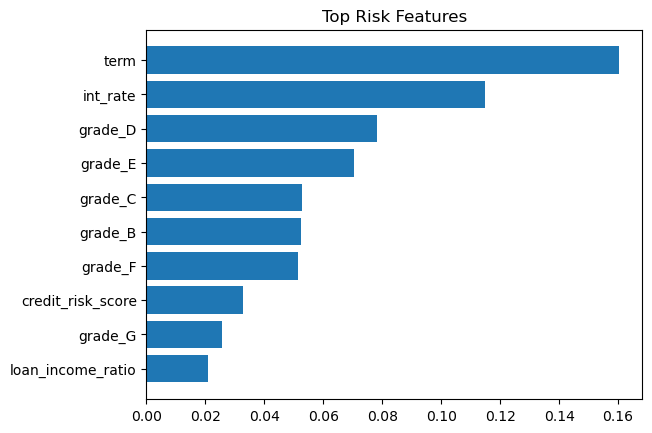

In [28]:
if best_model_name in ["Random Forest", "XGBoost"]:
    feature_importance = pd.DataFrame({
        "feature": X.columns,
        "importance": best_model.feature_importances_
    }).sort_values(by="importance", ascending=False)

    print("\nTop Risk Factors:")
    print(feature_importance.head(10))

    plt.figure()
    plt.barh(
        feature_importance["feature"].head(10),
        feature_importance["importance"].head(10)
    )
    plt.title("Top Risk Features")
    plt.gca().invert_yaxis()
    plt.show()

ROC Curve

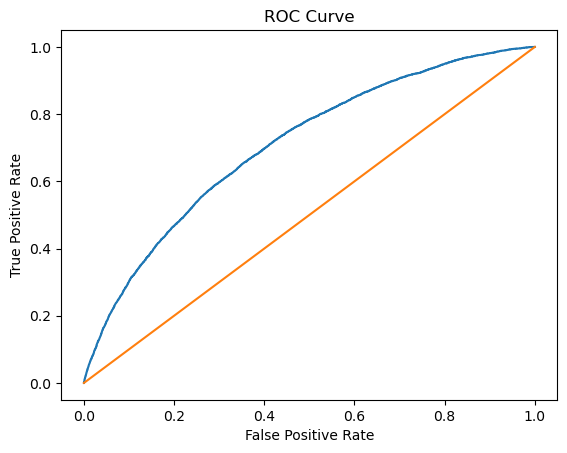

In [29]:
if best_model_name == "Logistic Regression":
    probs = best_model.predict_proba(X_test_scaled)[:, 1]
else:
    probs = best_model.predict_proba(X_test)[:, 1]

fpr, tpr, _ = roc_curve(y_test, probs)

plt.figure()
plt.plot(fpr, tpr)
plt.plot([0, 1], [0, 1])
plt.title("ROC Curve")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.show()

Save Best Model

In [30]:

joblib.dump(best_model, "model/loan_risk_model.pkl")

print("\nModel saved successfully!")


Model saved successfully!



Save Feature List (Important for API)

In [31]:
joblib.dump(list(X.columns), "model/features.pkl")

print("Feature list saved!")

Feature list saved!


Risk Score Function

In [33]:
def predict_risk(input_data):

    input_df = pd.DataFrame([input_data])

    if best_model_name == "Logistic Regression":
        input_df = scaler.transform(input_df)

    probability = best_model.predict_proba(input_df)[0][1]

    risk_score = probability * 100

    return {
        "default_probability": probability,
        "risk_score": risk_score
    }

print("\nTraining Complete")


Training Complete
